In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, roc_curve)
from sklearn.preprocessing import LabelEncoder
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/credit_risk_clean.csv")

print("Datos cargados OK")
print(f"Shape: {df.shape}")

Datos cargados OK
Shape: (32581, 12)


In [2]:
# Copiar dataset
data = df.copy()

# Imputar nulos
data["loan_int_rate"]    = data["loan_int_rate"].fillna(data["loan_int_rate"].median())
data["person_emp_length"] = data["person_emp_length"].fillna(data["person_emp_length"].median())

# Encodear variables categóricas
le = LabelEncoder()
cat_cols = ["person_home_ownership", "loan_intent", "loan_grade", "cb_person_default_on_file"]
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

# Features y target
FEATURES = [
    "person_age", "person_income", "person_home_ownership",
    "person_emp_length", "loan_intent", "loan_grade",
    "loan_amnt", "loan_int_rate", "loan_percent_income",
    "cb_person_default_on_file", "cb_person_cred_hist_length"
]

X = data[FEATURES]
y = data["loan_status"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Default rate train: {y_train.mean()*100:.1f}%")
print(f"Default rate test:  {y_test.mean()*100:.1f}%")

Train: 26,064 | Test: 6,517
Default rate train: 21.8%
Default rate test:  21.8%


In [3]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

y_pred       = rf_baseline.predict(X_test)
y_pred_proba = rf_baseline.predict_proba(X_test)[:, 1]

auc_baseline = roc_auc_score(y_test, y_pred_proba)

print("BASELINE MODEL — Random Forest (no inflation adjustment)")
print("=" * 55)
print(f"AUC-ROC: {auc_baseline:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Default", "Default"]))

BASELINE MODEL — Random Forest (no inflation adjustment)
AUC-ROC: 0.9121

Classification Report:
              precision    recall  f1-score   support

  No Default       0.91      0.99      0.95      5095
     Default       0.96      0.66      0.78      1422

    accuracy                           0.92      6517
   macro avg       0.93      0.82      0.86      6517
weighted avg       0.92      0.92      0.91      6517



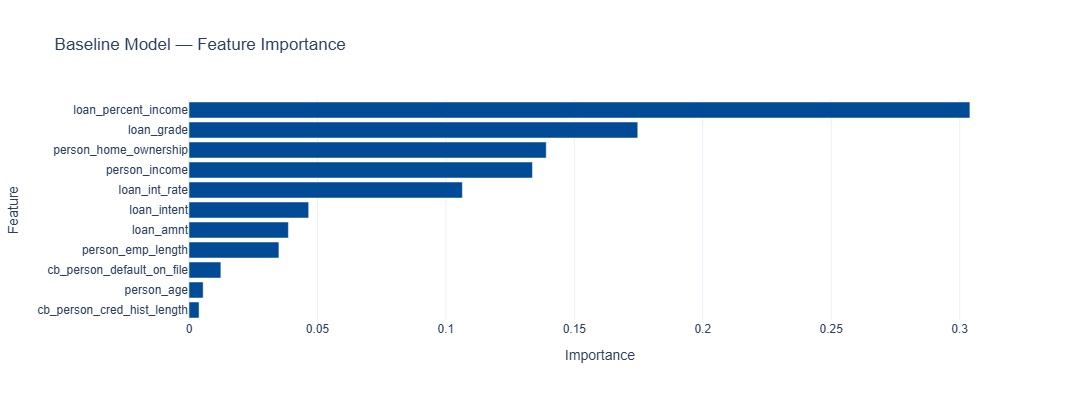

In [4]:
importance_df = pd.DataFrame({
    "feature":   FEATURES,
    "importance": rf_baseline.feature_importances_
}).sort_values("importance", ascending=True)

fig = go.Figure(go.Bar(
    x=importance_df["importance"],
    y=importance_df["feature"],
    orientation="h",
    marker_color="#004A96"
))

fig.update_layout(
    title="Baseline Model — Feature Importance",
    xaxis_title="Importance",
    yaxis_title="Feature",
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=400
)

fig.show()

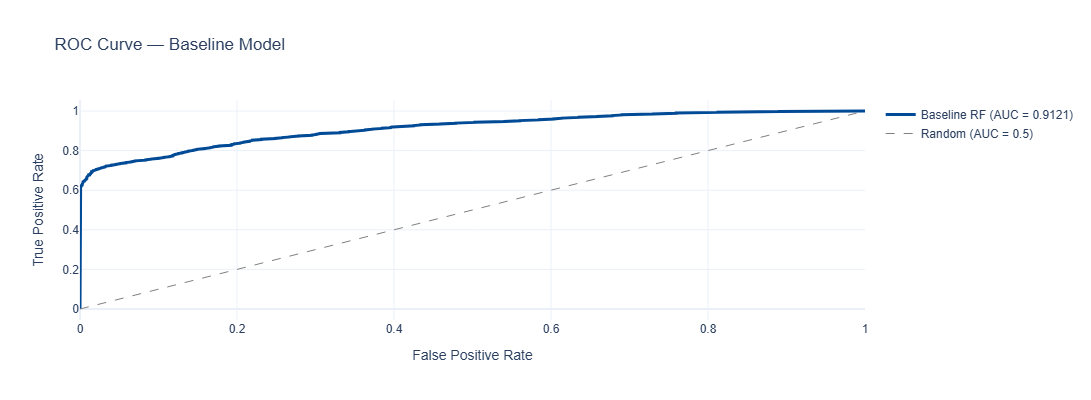


Baseline AUC guardado: 0.9121


In [5]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=fpr, y=tpr,
    mode="lines",
    name=f"Baseline RF (AUC = {auc_baseline:.4f})",
    line=dict(color="#004A96", width=3)
))

fig2.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode="lines",
    name="Random (AUC = 0.5)",
    line=dict(color="gray", width=1, dash="dash")
))

fig2.update_layout(
    title="ROC Curve — Baseline Model",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=400
)

fig2.show()

# Guardar métricas para comparación posterior
baseline_metrics = {
    "model": "Baseline RF",
    "auc":   round(auc_baseline, 4)
}
print(f"\nBaseline AUC guardado: {baseline_metrics['auc']}")

In [6]:
import pickle

with open("../outputs/rf_baseline.pkl", "wb") as f:
    pickle.dump(rf_baseline, f)

pd.DataFrame([baseline_metrics]).to_csv("../data/model_metrics.csv", index=False)

print("Guardado OK")
print(f"AUC Baseline: {auc_baseline:.4f}")

Guardado OK
AUC Baseline: 0.9121
